# Section Exploration #

Analysing the data from the first experiments first starts with loading the data

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import os 

asr_metrics = Path("output/transcription scoring")
asr_transcripts = Path("output/asr output")

metrics_df = pd.concat([pd.read_csv(asr_metrics / f) for f in os.listdir(asr_metrics)], ignore_index=True)
transcripts_df = pd.concat([pd.read_csv(asr_transcripts / f) for f in os.listdir(asr_transcripts)], ignore_index=True).drop(columns=["transcript"])

df = pd.merge(metrics_df, transcripts_df, on=["name", "category", "model"], how="inner")
df.head(5)

,name,category,model,num_words,num_sentences,char diff,wer_1,simdist_1,wer_2,simdist_2,wer_3,simdist_3,cpu_max,cpu_avg,gpu_max,gpu_avg,mem_max,mem_avg,rtfx
0,bewegingsapparaat.mp3,Dokter Patient,Whisper-large-v3-fast,598,60,1.4,0.087102,0.965309,0.079258,0.970466,0.079392,0.970466,87.8,37.545652,100,91.304348,4924.3125,4706.416848,361.429221
1,ademhaling.mp3,Dokter Patient,Whisper-large-v3-fast,191,21,2.3,0.057895,0.990376,0.057895,0.990376,0.057895,0.990376,83.7,44.266216,100,88.270270,4892.3125,4619.015203,430.492679
2,diabetes.mp3,Dokter Patient,Whisper-large-v3-fast,561,68,0.2,0.067857,0.975002,0.058824,0.976938,0.059041,0.976938,85.4,43.028922,100,92.078431,4924.3125,4723.528186,389.517450
3,hartziekten.mp3,Dokter Patient,Whisper-large-v3-fast,645,59,0.6,0.049689,0.980769,0.048513,0.982256,0.045383,0.982721,85.4,39.948052,100,91.969697,4924.3125,4719.567911,386.329943
4,oncologie.mp3,Dokter Patient,Whisper-large-v3-fast,583,58,-0.6,0.042955,0.984484,0.039861,0.987685,0.038261,0.988528,87.5,38.354327,100,91.350962,4956.3125,4709.235577,390.879602


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
original_df = df
df = original_df.copy()
df = df.rename(columns={'wer': 'wer_3', 'simdist': 'simdist_3'})
df.head()

,name,category,model,num_words,num_sentences,char diff,wer_1,simdist_1,wer_2,simdist_2,wer_3,simdist_3,cpu_max,cpu_avg,gpu_max,gpu_avg,mem_max,mem_avg,rtfx
0,bewegingsapparaat.mp3,Dokter Patient,Whisper-large-v3-fast,598,60,1.4,0.087102,0.965309,0.079258,0.970466,0.079392,0.970466,87.8,37.545652,100,91.304348,4924.3125,4706.416848,361.429221
1,ademhaling.mp3,Dokter Patient,Whisper-large-v3-fast,191,21,2.3,0.057895,0.990376,0.057895,0.990376,0.057895,0.990376,83.7,44.266216,100,88.270270,4892.3125,4619.015203,430.492679
2,diabetes.mp3,Dokter Patient,Whisper-large-v3-fast,561,68,0.2,0.067857,0.975002,0.058824,0.976938,0.059041,0.976938,85.4,43.028922,100,92.078431,4924.3125,4723.528186,389.517450
3,hartziekten.mp3,Dokter Patient,Whisper-large-v3-fast,645,59,0.6,0.049689,0.980769,0.048513,0.982256,0.045383,0.982721,85.4,39.948052,100,91.969697,4924.3125,4719.567911,386.329943
4,oncologie.mp3,Dokter Patient,Whisper-large-v3-fast,583,58,-0.6,0.042955,0.984484,0.039861,0.987685,0.038261,0.988528,87.5,38.354327,100,91.350962,4956.3125,4709.235577,390.879602


### Exploration of the dataset

The gathered data was split across 3 categories, ranging from 5 minutues to more than an out. They were mainly grouped around the 5 tot 15 minute mark. Below a graph of the distribution.

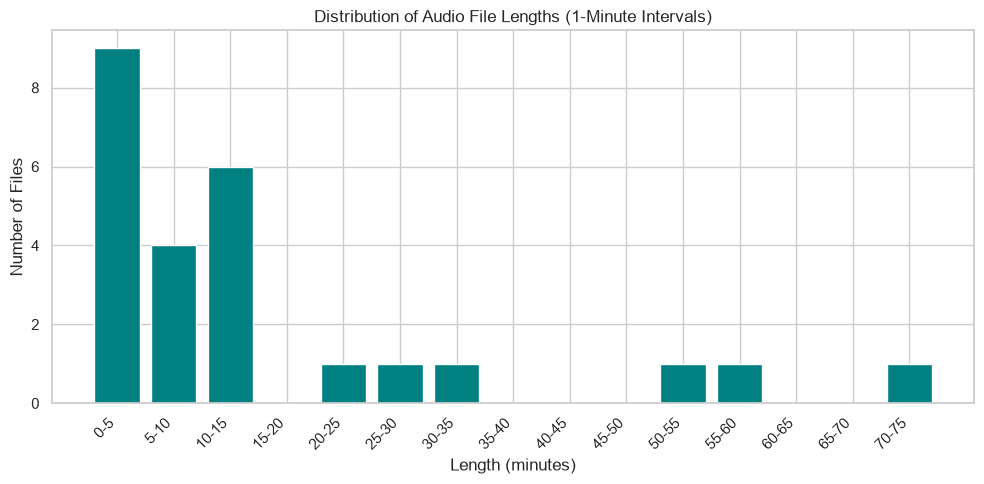

In [36]:
audio = {'bewegingsapparaat.mp3': 4.06,
 'ademhaling.mp3': 1.52,
 'diabetes.mp3': 3.08,
 'hartziekten.mp3': 3.48,
 'oncologie.mp3': 3.37,
 'abdomen.mp3': 3.33,
 'auto-immuunziekten.mp3': 4.32,
 'neurologie.mp3': 4.39,
 'misbruik.mp3': 9.59,
 'vrijheden.mp3': 9.06,
 'angststoornis.mp3': 3.06,
 'intake-bedrijf.mp3': 11.58,
 'baan.mp3': 13.26,
 'antidepressiva.mp3': 10.47,
 'studie.mp3': 8,
 'GGZ-exposure-therapie.mp3': 26.03,
 'interview-113.mp3': 8.40,
 'kpni-arts.mp3': 74.20,
 'ouderen-zorg.mp3': 33.56,
 'verzorgings-staat.mp3': 23,
 'hulpverleners.mp3': 10.50,
 'ouderen-zorg-2.mp3': 54.54,
 'seksuele-voorlichting.mp3': 14.36,
 'ouder-worden-2040.mp3': 10.52,
 'verpleegkundige-gevangenis.mp3': 55.08}

bins = np.arange(0, 80, 5)

bucketed = pd.cut(list(audio.values()), bins=bins, right=False)
counts = bucketed.value_counts().sort_index()

labels = [f"{int(b.left)}-{int(b.right)}" for b in counts.index]

plt.figure(figsize=(10, 5))
plt.bar(labels, counts.values, color="teal")
plt.title("Distribution of audio File lengths")
plt.xlabel("Length (minutes)")
plt.ylabel("Number of Files")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Average WER and SimDist after levels of abstraction

As mentioned in the methodology there are different levels of abstraction. In this case level 1 is only punctuation and level 3 removes sequencial words as well. The levels of abstraction are plotted onto the x-axis while the average WER and SimDist are plotted in different graphs on the y-axis. It is expected that as you remove random words at the same place from both the ground truth and the hypothesis that the scores do not change, unless they are more commonly predicted incorrectly compared to other words. The downwards slope of the average WER show that ASR models are bad at quessing sentences that are unlogical, contain filler words and/or use unofficial variants of words. This is to be expected since these large end-to-end models already incorporate sementic algorithms in their decoders and some even LLMs. This makes saying whats right preferable over what is actually being said. For instance it often prefers 'hij' over 'ie' and it will often cut of the beginning of sentences if they are abondent early by the speaker like "ik ga ik wil denk ik gaan" will become "ik wil denk ik gaan". In practice this is a good thing and makes the output of ASR models cleaner and easier to work with. The take away is that errors in these models are often in places that are not necessarily relevant to the core idea of the text. This concept is further explored during experiment 2 when the correlation between transcript and summary quality are meassured directly.

The average SimDist just like the WER benifits from these abstractions, however what the graph doesn't properly show due to the intervals at the y-axis is that the decrese in WER (around 20%) is way higher than the increase in SimDist (which is smaller than 2%). What this tells is that SimDist performance is pratically not affected by these normalizations. This makes it way more easy to implement as a strategy, making it possible to skip normalization entirely without any real lose of information.

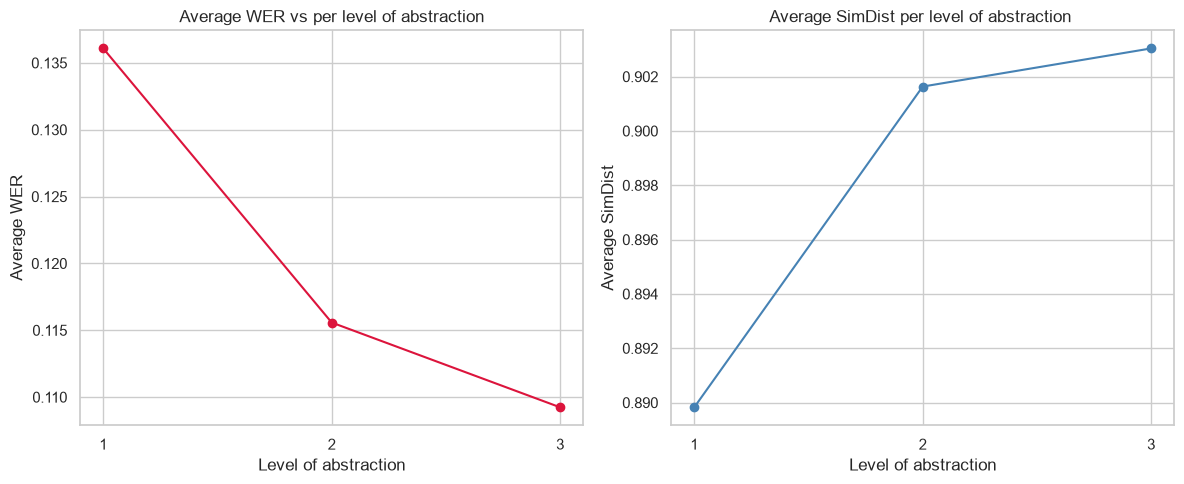

In [41]:
wer_cols = ["wer_1", "wer_2", "wer"]
simdist_cols = ["simdist_1", "simdist_2", "simdist"]

avg_wer = df[wer_cols].mean()
avg_simdist = df[simdist_cols].mean()
x_vals = [1, 2, 3]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(x_vals, avg_wer.values, marker="o", color="crimson")
axes[0].set_title("Average WER vs per level of abstraction")
axes[0].set_xlabel("Level of abstraction")
axes[0].set_ylabel("Average WER")
axes[0].set_xticks(x_vals)

axes[1].plot(x_vals, avg_simdist.values, marker="o", color="steelblue")
axes[1].set_title("Average SimDist per level of abstraction ")
axes[1].set_xlabel("Level of abstraction")
axes[1].set_ylabel("Average SimDist")
axes[1].set_xticks(x_vals)

plt.tight_layout()
plt.show()

Just a quick look at the different models them selfs to see if any model performce better under certained curcuimstances but this doesn't seem to be the case

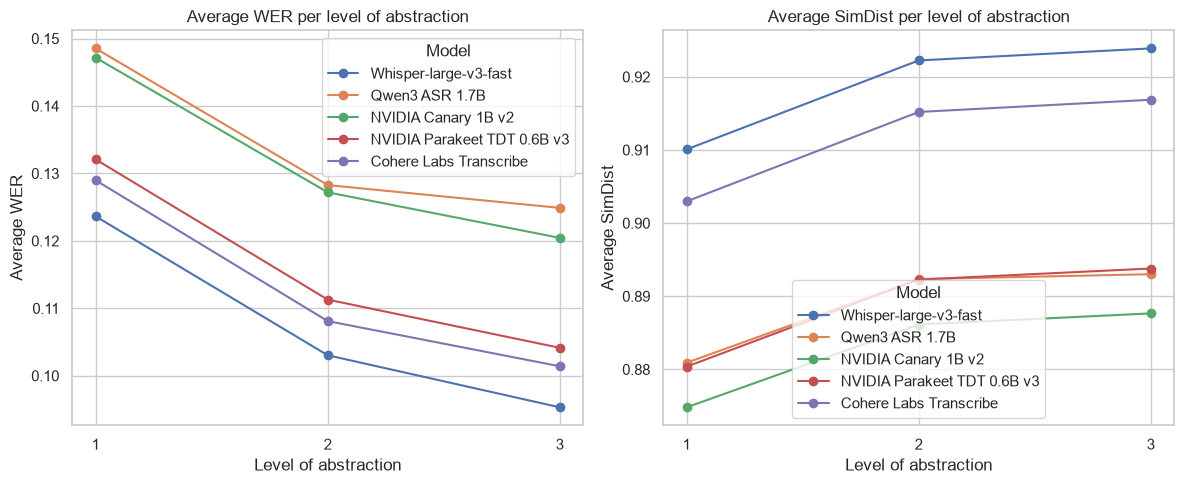

In [5]:
wer_cols = ["wer_1", "wer_2", "wer_3"]
simdist_cols = ["simdist_1", "simdist_2", "simdist_3"]
x_vals = [1, 2, 3]

models = df["model"].unique()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for model in models:
    model_df = df[df["model"] == model]
    avg_wer = model_df[wer_cols].mean()
    avg_simdist = model_df[simdist_cols].mean()

    axes[0].plot(x_vals, avg_wer.values, marker="o", label=model)
    axes[1].plot(x_vals, avg_simdist.values, marker="o", label=model)

axes[0].set_title("Average WER per level of abstraction")
axes[0].set_xlabel("Level of abstraction")
axes[0].set_ylabel("Average WER")
axes[0].set_xticks(x_vals)
axes[0].legend(title="Model")

axes[1].set_title("Average SimDist per level of abstraction")
axes[1].set_xlabel("Level of abstraction")
axes[1].set_ylabel("Average SimDist")
axes[1].set_xticks(x_vals)
axes[1].legend(title="Model")

plt.tight_layout()
plt.show()

### Model Performance vs. General Benchmarks

From now on, WER_3 and SimDist_3 will be used for all the remaining analyses and they will be referred to as just WER and SimDist from now on. These models have already been benchmarked on large english datasets and even dutch ones. This section compares those scores to the ones gathered in this research. It looks only at WER and RTFx since SimDist in not commonly used in other populair benchmarks. For each model it plots a bar chart with 3 bars for each of the WER and RTFx scores right next to eachother for both the score obtained in this research, the scores on the ASR-Leaderboards (last updated 16th of July \cite[https://huggingface.co/spaces/hf-audio/open_asr_leaderboard] and on the ASR Dutch leaderboards \cite[https://huggingface.co/spaces/tvosch/Dutch-ASR-Leaderboard]. As expected do the models perform worse on dutch in general compared to english. This is because the models are finetuned on multilingual audio they remain at their core english models. As well as english audio being far more accessible due to it being the most common spoken language in the western world compared to dutch. The dutch one was benched against FLEURS \cite[https://huggingface.co/datasets/google/fleurs] a well articulated single speaker dataset of very short fragments, VoxPopuli \cite[https://huggingface.co/datasets/facebook/voxpopuli/viewer/cs/train?sort%5Bcolumn%5D=language&sort%5Bdirection%5D=desc] shorter fragments up to a minute of public speakers in parlement, formal but a bit looser than the other two and Multi Lingual Librespeech (MSL) \cite[https://huggingface.co/datasets/facebook/multilingual_librispeech] which are short audiobook readings. Literature would suggest that due to the nature of speech of the dataset gathered in this research that the benchmark on this data would result in worse audio scores than the other dutch one which is the case but not by much.

The RTFx data is hard to use since I couldn't find the exact hardware specifications that were used or which methods. The scores on the leader boards stem from real attempts at maximizing RTFx without compromising on accuract. Instead in this research the models were set up just to run without any  
optimization. This can be done through batching, and different preprossesing steps for example.

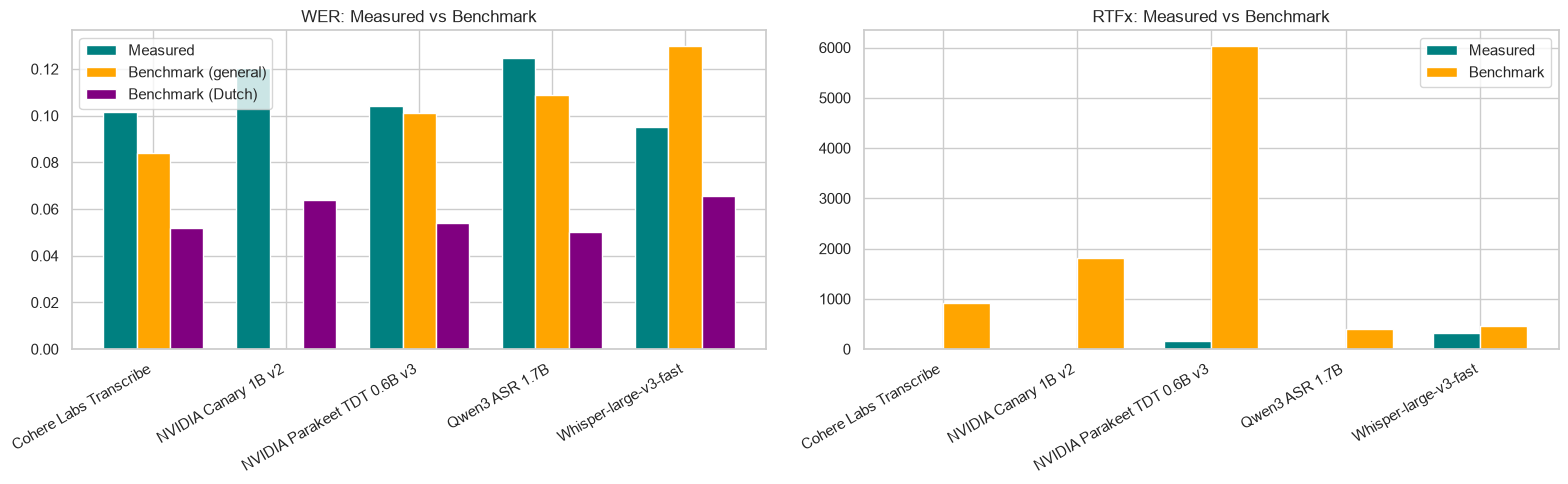

In [28]:
df = df.rename(columns={'wer_3': 'wer', 'simdist_3': 'simdist'})

benchmark_scores = {
    "Cohere Labs Transcribe": {"wer_benchmark": 0.052, "wer_benchmark_dutch": 0.084, "rtfx_benchmark": 915.58},
    "NVIDIA Canary 1B v2": {"wer_benchmark": 0.0639, "wer_benchmark_dutch": 0, "rtfx_benchmark": 1821.44},
    "NVIDIA Parakeet TDT 0.6B v3": {"wer_benchmark": 0.0539, "wer_benchmark_dutch": 10.1, "rtfx_benchmark": 6038.1},
    "Qwen3 ASR 1.7B": {"wer_benchmark": 0.0502, "wer_benchmark_dutch": 10.9, "rtfx_benchmark": 394.113},
    "Whisper-large-v3-fast": {"wer_benchmark": 0.0655, "wer_benchmark_dutch": 13.0, "rtfx_benchmark": 462.22},
}

benchmark_scores_dutch = {
    "Cohere Labs Transcribe": 0.084,
    "NVIDIA Canary 1B v2": 0,
    "NVIDIA Parakeet TDT 0.6B v3": 0.101,
    "Qwen3 ASR 1.7B": 0.109,
    "Whisper-large-v3-fast": 0.130,
}

model_stats = df.groupby("model")[["wer", "rtfx"]].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

measured_wer = model_stats.set_index("model")["wer"]
benchmark_wer = pd.Series({m: benchmark_scores.get(m, {}).get("wer_benchmark", np.nan)
                            for m in measured_wer.index})
benchmark_wer_dutch = pd.Series({m: benchmark_scores_dutch.get(m, np.nan)
                                  for m in measured_wer.index})

x = np.arange(len(measured_wer))
width = 0.25

axes[0].bar(x - width, measured_wer.values, width, label="Measured", color="teal")
axes[0].bar(x, benchmark_wer_dutch.values, width, label="Benchmark (general)", color="orange")
axes[0].bar(x + width, benchmark_wer.values, width, label="Benchmark (Dutch)", color="purple")
axes[0].set_xticks(x)
axes[0].set_xticklabels(measured_wer.index, rotation=30, ha="right")
axes[0].set_title("WER: Measured vs Benchmark")
axes[0].legend()

measured_rtfx = model_stats.set_index("model")["rtfx"]
benchmark_rtfx = pd.Series({m: benchmark_scores.get(m, {}).get("rtfx_benchmark", np.nan)
                             for m in measured_rtfx.index})

width2 = 0.35
axes[1].bar(x - width2/2, measured_rtfx.values, width2, label="Measured", color="teal")
axes[1].bar(x + width2/2, benchmark_rtfx.values, width2, label="Benchmark", color="orange")
axes[1].set_xticks(x)
axes[1].set_xticklabels(measured_rtfx.index, rotation=30, ha="right")
axes[1].set_title("RTFx: Measured vs Benchmark")
axes[1].legend()

plt.tight_layout()
plt.show()

### Change in share of total WER meassured - dutch

It was expected that the WER score would increase and accuracy would be down across all models due the the dataset used as discussed in the previous section. In this section the relative increase in WER is compared between models using their share of the total WER. The total sum of WER scores from both the existing english benchmark and the dutch one are taken respectively. Than the share of each model as a procentage is calculated by deviding it over the sum. Than finally the difference in percentage points between those shares is taken to see which model out and underperformed. It is expected that each model has the same relative increase. However this is not the case as can be seen in the graph below. Qwen preformed way worse on dutch audio and cohere outperformed expectations. This makes Cohere stand out as the best ASR models for dutch audio when it comes to accuracy.

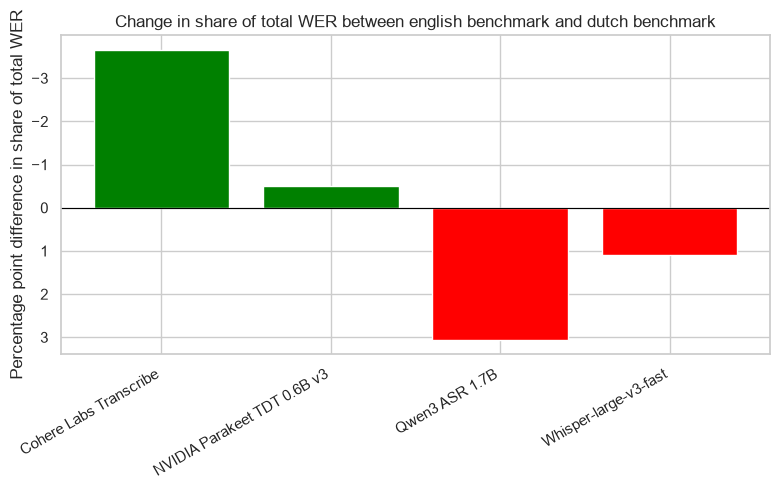

In [7]:
valid_english = pd.Series({m: v["wer_benchmark"] for m, v in benchmark_scores.items()})
valid_dutch = pd.Series({m: v for m, v in benchmark_scores_dutch.items() if v > 0})

# Only models with a valid Dutch benchmark (Canary excluded)
common_models = valid_dutch.index.intersection(valid_english.index)

dutch = valid_dutch[common_models]
english = valid_english[common_models]

# Percentage share of total each model represents, within each set
dutch_share = (dutch / dutch.sum()) * 100
english_share = (english / english.sum()) * 100

# Difference in percentage points
share_diff = dutch_share - english_share

colors = ["red" if v > 0 else "green" for v in share_diff.values]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(share_diff.index, share_diff.values, color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.invert_yaxis()  # increase (red) points downward
ax.set_title("Change in share of total WER between english benchmark and dutch benchmark")
ax.set_ylabel("Percentage point difference in share of total WER")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Change in share of total WER meassured - english benchmark

When looking at the same shift but from the english benchmark to the meassured scores we see a similair under performance of Qwen on dutch audio. What is different though is Whisper-large-v3-fast and Cohere. In the current setup Whisper achieves incredible WER scores. Where it previously ranked last on both benchmarks it now performce the best. This is likely due to the fact that during the creation of the baseline ground truth files, whisper was used as the base line transcript to change for around 40% of the files. Eventhough these were put through a different GenAI model first to assign speakers and fix obvious mistakes as well as being riggeresly edited and corrected using the reference audio file by hand, small human errors can still slip into the ground truth. And incase they do, say a small error was not spotted, they favor the model that created the transcript. There is no real way of adjusting for this and would require a redo of every single ground truth file, rewritten them using a different asr model or double checking all of them to confirm. All these scores can still be used for the second experiment since the WER and SimDist do reflect accuracte scorings just that the ground truth transcript might contain slight deviations from the true transcripts which favor Whisper.

Cohere Labs underperforce compared to how well it did at the other 2 but it still does the best outof any of the models, if you ignore Whisper.

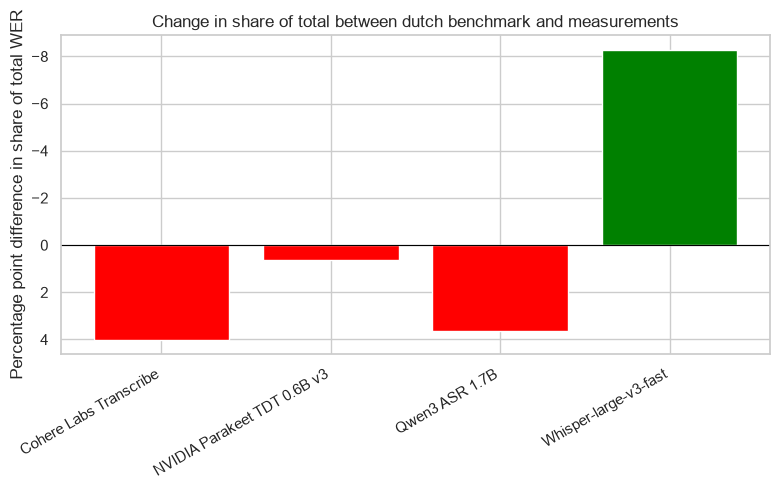

In [8]:
measured_wer = df.groupby("model")["wer"].mean()

valid_dutch = pd.Series({m: v for m, v in benchmark_scores_dutch.items() if v > 0})
common_models = measured_wer.index.intersection(valid_dutch.index)

measurements = measured_wer[common_models]
bench = valid_dutch[common_models]

measurements_share = (measurements / measurements.sum()) * 100
bench_share = (bench / bench.sum()) * 100

share_diff = measurements_share - bench_share

colors = ["red" if v > 0 else "green" for v in share_diff.values]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(share_diff.index, share_diff.values, color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.invert_yaxis()  # increase (red) points downward
ax.set_title("Change in share of total between dutch benchmark and measurements")
ax.set_ylabel("Percentage point difference in share of total WER")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### More analysis on model performance

Using a boxplot, it becomes clear that almost every model performed similair to eachother for the most part, except for whipser which outperformed the rest by quite a bit both for the WER and SimDist. It also shows that Qwen and Canary suffer from hallucinations in the current setup. If not accounting for Whipser given the suspected biases in the model, cohere having the highest consistency, average scores, and lowest bad and highest good scoring for both WER and SimDist.

C:\Users\thoma\AppData\Local\Temp\ipykernel_23680\3893409504.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="model", y="wer", palette="tab10", ax=axes[0])
C:\Users\thoma\AppData\Local\Temp\ipykernel_23680\3893409504.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="model", y="simdist", palette="tab10", ax=axes[1])


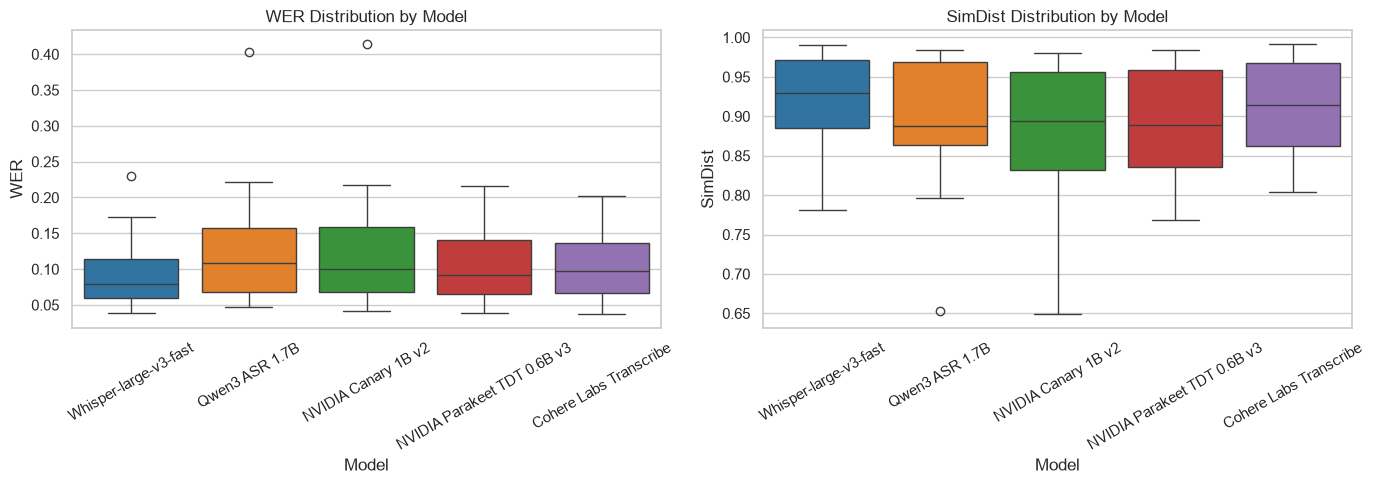

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="model", y="wer", palette="tab10", ax=axes[0])
axes[0].set_title("WER Distribution by Model")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("WER")
axes[0].tick_params(axis="x", rotation=30)

sns.boxplot(data=df, x="model", y="simdist", palette="tab10", ax=axes[1])
axes[1].set_title("SimDist Distribution by Model")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("SimDist")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### Average WER across categories

The WER score for the 'Dokter Patient' category is almost half of that of the other categories. This was to be expected as those audio files were short scripted conversations with high quality audio, no overlapping speakers and no informal sequences. Unlike the others which were humans having real spontaneous conversations. This graph does show how well SimDist works. It filters out all the irrelevant errors made during these sections and outputs very similair scores across all categories.

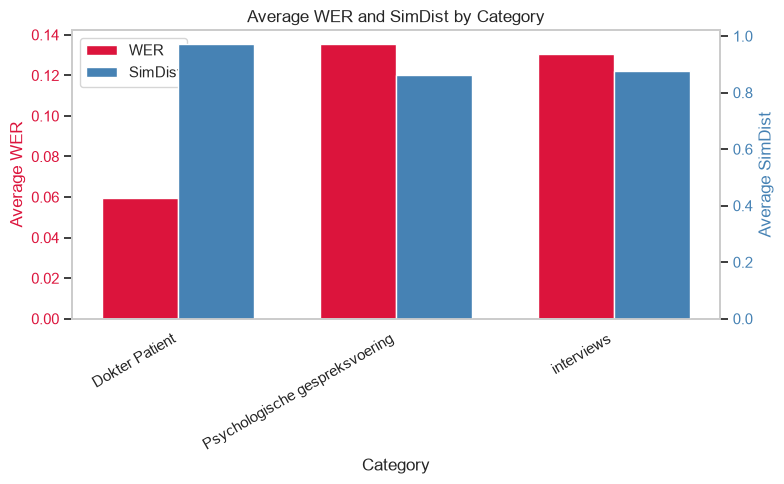

In [16]:
categories = df["category"].unique()
category_avg = df.groupby("category")[["wer", "simdist"]].mean().reindex(categories)

x = np.arange(len(categories))
width = 0.35

fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

b1 = ax1.bar(x - width/2, category_avg["wer"], width, color="crimson", label="WER")
b2 = ax2.bar(x + width/2, category_avg["simdist"], width, color="steelblue", label="SimDist")

ax1.set_xlabel("Category")
ax1.set_ylabel("Average WER", color="crimson")
ax1.tick_params(axis="y", labelcolor="crimson")

ax2.set_ylabel("Average SimDist", color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")

ax1.set_xticks(x)
ax1.set_xticklabels(categories, rotation=30, ha="right")
ax1.set_title("Average WER and SimDist by Category")

ax1.grid(False)
ax2.grid(False)

ax1.legend(handles=[b1, b2], loc="upper left")

plt.tight_layout()
plt.show()

### Average WER across audio file lengths

The files are ordend in 3 buckets, 0-20 minutes, 20-40 minutes and 40+. The sample size is to small to make any assumptions on ASR performance on larger audio fragments. The lower scores in the 0-20 bucket is mainly caused by the 'Dokter Patient' category reducing overall WER and SimDist. 

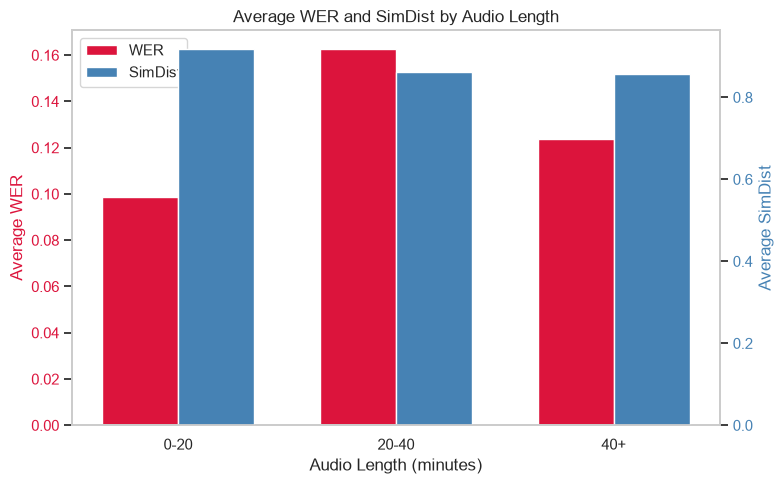

In [45]:
df["length_min"] = df["name"].map(pd.Series(audio))

bins = [0, 20, 40, np.inf]
bucket_labels = ["0-20", "20-40", "40+"]
df["length_bucket"] = pd.cut(df["length_min"], bins=bins, labels=bucket_labels, right=False)

bucket_avg = df.groupby("length_bucket")[["wer", "simdist"]].mean().reindex(bucket_labels)

x = np.arange(len(bucket_labels))
width = 0.35

fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

b1 = ax1.bar(x - width/2, bucket_avg["wer"], width, color="crimson", label="WER")
b2 = ax2.bar(x + width/2, bucket_avg["simdist"], width, color="steelblue", label="SimDist")

ax1.set_xlabel("Audio Length (minutes)")
ax1.set_ylabel("Average WER", color="crimson")
ax1.tick_params(axis="y", labelcolor="crimson")

ax2.set_ylabel("Average SimDist", color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")

ax1.set_xticks(x)
ax1.set_xticklabels(bucket_labels)
ax1.set_title("Average WER and SimDist by Audio Length")

ax1.grid(False)
ax2.grid(False)

ax1.legend(handles=[b1, b2], loc="upper left")

plt.tight_layout()
plt.show()

### SimDist vs WER

When comparing WER to SimDist performance, the paper that created the SimDist \cite[https://arxiv.org/pdf/2104.02138] suggests that there would be a clear relationship between these with an R-squared of around 0.42 to 0.52. this make sense since the sementic meaning affects one metric but not the other creating a second factor that influences the score. To check the relation, the WER and SimDist for every transcript is plotted onto a single graph. Using a simple linear regression model, a line can be constructed that minimizes the distances between it and every point. However in this run the correlation is much stronger with an R-squared of 0.85. This would imply that SimDist in its current form is not as good at capturing sementic differences and is rather measuring pure accuracy just like WER is. It does still show that the variance along side the line increases when the WER goes up. Ultimately the conclution of the paper still holds that SimDist is a good alternative to WER.

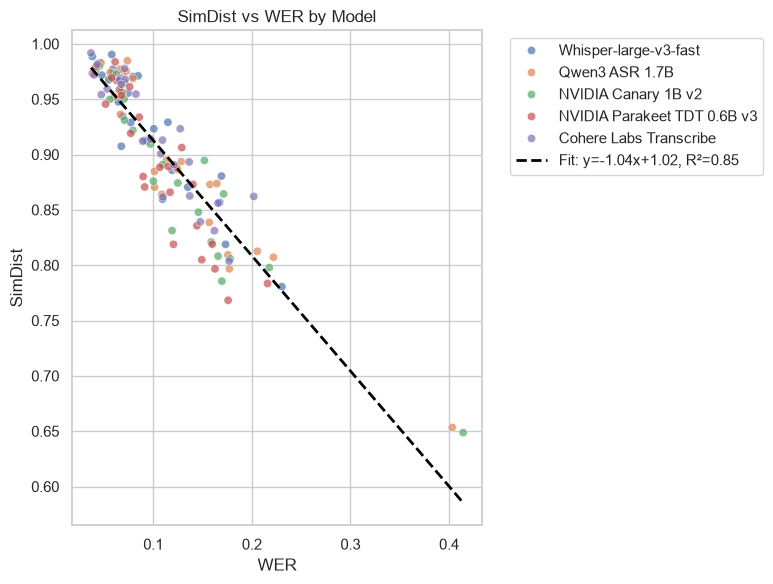

In [44]:
from scipy import stats

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="wer", y="simdist", hue="model", alpha=0.7)

slope, intercept, r_value, p_value, std_err = stats.linregress(df["wer"], df["simdist"])

x_line = np.linspace(df["wer"].min(), df["wer"].max(), 100)
y_line = slope * x_line + intercept

plt.plot(x_line, y_line, color="black", linewidth=2, linestyle="--",
          label=f"Fit: y={slope:.2f}x+{intercept:.2f}, R²={r_value**2:.2f}")

plt.title("SimDist vs WER by Model")
plt.xlabel("WER")
plt.ylabel("SimDist")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Model performance

does not really show anything just that the models are not optimized properly for performance accept for whisper

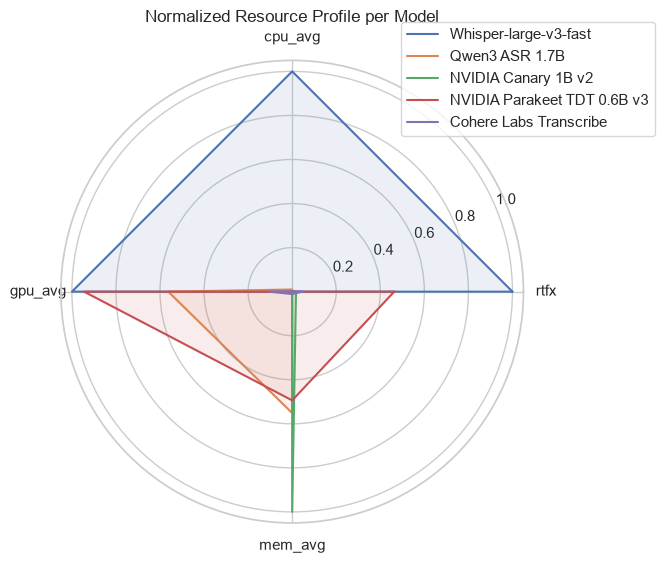

In [51]:
from math import pi

resource_cols = ["rtfx", "cpu_avg", "gpu_avg", "mem_avg"]
model_resources = df.groupby("model")[resource_cols].mean()

norm = (model_resources - model_resources.min()) / (model_resources.max() - model_resources.min())

labels = resource_cols
num_vars = len(labels)
angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for model in ['Whisper-large-v3-fast', 'Qwen3 ASR 1.7B', 'NVIDIA Canary 1B v2', 'NVIDIA Parakeet TDT 0.6B v3', 'Cohere Labs Transcribe']:
    
    values = norm.loc[model].tolist()
    values += values[:1]
    ax.plot(angles, values, label=model)
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:1])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_title("Normalized Resource Profile per Model")
ax.legend(bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()


### Possible things to analyse

**adjusting for n_words for each file**, **heatmap for model/category or model/time and or n_words**, **removing outliers from the model**, **analysing which audio files were transcript well and which ones not**

### conclution

The results show that these ASR models are quite capable at transcribing dutch conversations about healthcare, in a interview setting or as real conversations. It generally performce relatively similair to the same models on general dutch datasets but slightly worse. Whisper showed the best results but due to the bias introduced during the creation of the ground truth files this cannot be taken at face value. The performance of Cohere however the second best performing model does reflect the potential as a great alternative. The incredible low usage of resources leaves room for optimizations which should increase the speed. Qwen performce worse on both non english benchmarks even with the removale of the outlier. Canary was not benchmarked on the dutch benchmark so it can not be compared but it also did poorly during the experiment. Parakeet remains consistent through out.

SimDist has shown to be a great way of calculating accuracy. It stays consistent through noise in the audio files making normalization absolete. It packs more information and is especially important once the WER score start to rise. This metric will propably be stronger correlated to the summary scores than WER.

### Experiment 2: Correlation between Transcript scores and Summarization scores